In [8]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\Taizeen\Downloads\data science assignments\MLR\MLR\ToyotaCorolla - MLR.csv")

print (df.head())

print (df.info())

print(df.describe())

print(df.isnull().sum())

df=pd.get_dummies(df,columns=['Fuel_Type'],drop_first=True)


   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null  

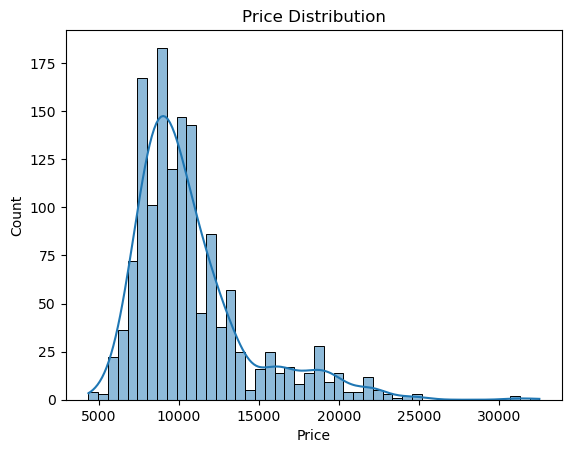

In [6]:
sns.histplot(df['Price'],kde=True)
plt.title("Price Distribution")
plt.show()

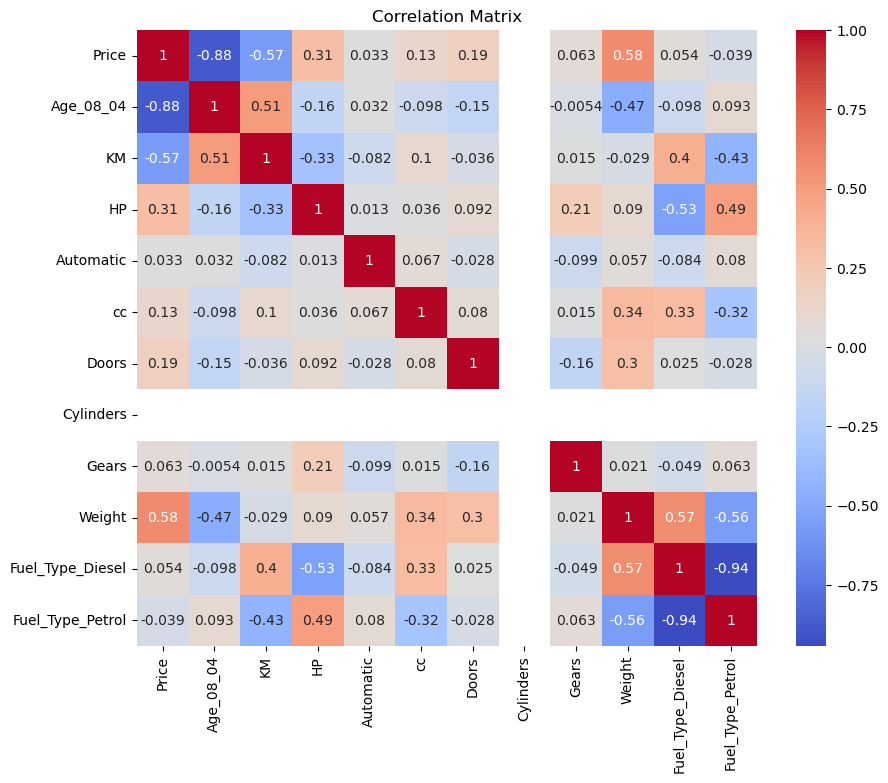

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
x=df.drop('Price',axis=1)
y=df['Price']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression
model1= LinearRegression()
model1.fit(x_train,y_train)
coefficients= pd.DataFrame({
    "Feature":x.columns,
    "Coefficient":model1.coef_})
print(coefficients)

             Feature   Coefficient
0          Age_08_04 -1.208305e+02
1                 KM -1.623141e-02
2                 HP  1.403948e+01
3          Automatic  1.488309e+02
4                 cc -3.037219e-02
5              Doors -6.031097e+01
6          Cylinders -8.242296e-13
7              Gears  5.516007e+02
8             Weight  2.588496e+01
9   Fuel_Type_Diesel -6.854876e+01
10  Fuel_Type_Petrol  1.370809e+03


In [15]:
features= ['Age_08_04','KM','HP','Weight']
x2=df[features]
y2=df['Price']
x_train2,x_test2,y_train2,y_test2=train_test_split(x2,y2,test_size=0.2,random_state=42)
model2=LinearRegression()
model2.fit(x_train2,y_train2)

LinearRegression()

In [17]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_scaled = scaler.fit_transform(x)
x_train3,x_test3,y_train3,y_test3=train_test_split(
    x_scaled,y,test_size=0.2,random_state=42
)
model3=LinearRegression()
model3.fit(x_train3,y_train3)

LinearRegression()

In [18]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
y_pred=model1.predict(x_test)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print("R2 Score:",r2)
print("MAE:",mae)
print("RMSE:",rmse)


R2 Score: 0.8348888040611082
MAE: 990.8872739193923
RMSE: 1484.2654153296512


In [19]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(x_train,y_train)
ridge_pred= ridge.predict(x_test)
print("Ridge R2:",r2_score(y_test,ridge_pred))

Ridge R2: 0.8351359377712337


In [21]:
from sklearn.linear_model import Lasso
Lasso = Lasso(alpha=0.1)
Lasso.fit(x_train,y_train)
Lasso_pred= Lasso.predict(x_test)
print("Lasso R2:",r2_score(y_test,Lasso_pred))

Lasso R2: 0.8349467801805
